# carbitrage: a worked comparison, start to finish

Four mutually exclusive ways to be mobile for the next six years. They have
different lifetimes, different acquisition modes, different energy carriers and
different subsidy regimes, so they cannot be compared by adding up costs.

This notebook builds the case from scratch, ranks it, and then does the part
that actually matters: finding **at what parameter value the answer flips**.

In [1]:
from datetime import date

from IPython.display import Markdown, display

from carbitrage import (
    BAFA2026,
    LPG,
    Alternative,
    BivalentSource,
    Electricity,
    GeometricDecline,
    Household,
    Incumbent,
    Lease,
    Petrol,
    Purchase,
    Range,
    ReplacementChain,
    TabulatedResiduals,
    ThgQuote,
    Timeline,
    Triangular,
    Usage,
    Vehicle,
    VehicleTaxExemption,
    advantage,
    compare,
    optimal_replacement_age,
    resolve,
)

md = lambda text: display(Markdown(text))  # noqa: E731 - renders the library's tables

## 1. The assumptions every alternative shares

The `Timeline` is the common horizon: how long, how finely, at what discount
rate, and how prices grow. Everything else in the library discounts against it.
`Usage` and `Household` are shared too — the same mileage and the same buyer
apply to every option, which is what makes them comparable.

In [2]:
timeline = Timeline(
    horizon_years=6,
    periods_per_year=12,          # monthly grid; rate converted conformally
    rate=0.03,                    # nominal cost of capital p.a.
    energy_escalation=0.02,
    vehicle_price_escalation=0.015,
)

usage = Usage(annual_km=12_000)
household = Household(taxable_income=55_000, children=0)

## 2. The asset

A `Vehicle` is pure data. It does not know how it is paid for, who buys it, or
how far it is driven — those live in the acquisition mode, the household and
the usage profile. That separation is what lets the *same* vehicle appear in a
purchase, a lease and a replacement chain without being redefined.

Two things are pluggable: how it is fuelled (`Electricity`, `Petrol`, `LPG`,
`BivalentSource`, …) and how it loses value (`GeometricDecline`,
`FirstYearDropThenGeometric`, `TabulatedResiduals`).

In [3]:
ev = Vehicle(
    name="Hyundai Inster",
    price=23_900,
    energy=Electricity(
        consumption=15.1,          # kWh/100 km, WLTP
        real_world_factor=1.18,    # what it actually draws
        home_price=0.30,
        public_price=0.55,
        home_share=0.8,
    ),
    residual=GeometricDecline(0.15),   # 15 % of value lost per year
    insurance=750,
    maintenance=300,
    setup_cost=1_500,                  # the wallbox: paid whenever this car arrives
    first_registration=date(2026, 1, 1),
)

petrol_car = Vehicle(
    name="Petrol equivalent",
    price=22_000,
    energy=Petrol(consumption=6.0, price=2.10),
    residual=GeometricDecline(0.13),
    insurance=650,
    maintenance=550,
    annual_tax=150,
)

### The car already owned

The incumbent enters at its **current market value**, never at what was paid for
it. Past spend is sunk and has no representation anywhere in the model; the
€1,500 it would fetch today is an inflow to every alternative that sells it and
a forgone inflow to the one that keeps it.

In [4]:
incumbent_car = Vehicle(
    name="LPG incumbent",
    price=1_500,                        # today's market value
    energy=BivalentSource(              # 90 % autogas, 10 % petrol
        primary=LPG(consumption=7.5, price=0.99, volumetric_penalty=1.2),
        secondary=Petrol(consumption=7.5, price=2.10),
        primary_share=0.90,
    ),
    residual=TabulatedResiduals.from_values(1_500, {2: 800}),
    insurance=550,
    maintenance=900,
    annual_tax=160,
)

incumbent = Incumbent(vehicle=incumbent_car, market_value=1_500)

## 3. Alternatives: an asset, plus how it is paid for

`Alternative` binds a vehicle to an acquisition mode (`Purchase`, `Lease`,
`Financed`) and to the incentives it attracts. Operating costs stay on the
vehicle, because they are incurred whether it is bought or leased.

Incentives check their own eligibility: the 2026 purchase premium is
means-tested, new-vehicles-only, and lands with a disbursement lag rather than
at t=0 — which matters once it is discounted.

In [5]:
incentives = (
    BAFA2026(disbursement_lag_months=4),   # means-tested purchase premium
    ThgQuote(annual_amount=300),           # greenhouse-gas quota credit, BEV only
    VehicleTaxExemption(),
)

A1 = "EV, bought now"
A2 = "EV, leased"
A3 = "Petrol car, bought now"
A4 = "Keep the LPG car, EV in 2 years"

buy_ev = Alternative(vehicle=ev, acquisition=Purchase(), incentives=incentives, label=A1)

lease_ev = Alternative(
    vehicle=ev,
    acquisition=Lease(
        monthly_rate=239,
        term_months=36,               # two chained contracts cover the 6 years
        included_km=10_000,
        excess_km_rate=0.12,
        renewal_escalation=0.05,      # the second contract is dearer
    ),
    incentives=incentives,
    label=A2,
)

buy_petrol = Alternative(vehicle=petrol_car, acquisition=Purchase(), label=A3)

## 4. Unequal lives need a chain

The interesting option — repair the old car, run it two more years, then buy the
EV — does not cover the horizon on its own. Comparing it by raw present value
against a six-year option would be meaningless, so the library refuses:

In [6]:
from carbitrage import UnequalLivesError

keep_it = Alternative(
    vehicle=incumbent_car,
    acquisition=Purchase(upfront_extra=2_500, already_owned=True),  # the repair
    life_years=2,
    disposes_incumbent=False,       # this is the option that keeps the old car
    label="LPG incumbent",
)

try:
    compare([buy_ev, keep_it], timeline, usage=usage)
except UnequalLivesError as exc:
    print(exc)

these alternatives are shorter than the 6-year horizon: LPG incumbent (2 y).  Comparing them by present value would credit the others with service these do not deliver.  Either wrap each in a ReplacementChain so that all alternatives cover the horizon, or pass allow_unequal_lives=True and read only the equivalent annual costs.


A `ReplacementChain` fixes that by running a successor after it. The start
period of the second leg is an economic quantity, not plumbing: it fixes the
car's age at the horizon (four years, not six, so a different residual), the
vintage of its price (escalated two years) and when the subsidy disburses.

In [7]:
defer = ReplacementChain(
    keep_it,
    Alternative(vehicle=ev, acquisition=Purchase(), incentives=incentives, label="EV in 2028"),
    label=A4,
)

## 5. The comparison

`compare` evaluates every alternative on one monthly cash-flow grid and ranks
them by net present value. Costs are negative throughout; `PV of outflows` just
flips the sign for reading — it is not an `abs()`.

In [8]:
result = compare(
    [buy_ev, lease_ev, buy_petrol, defer],
    timeline,
    usage=usage,
    household=household,
    incumbent=incumbent,
)

md(result.to_markdown())
print(result.verdict())

| # | Alternative | PV of outflows | EAC / year | Cost / km | vs. Petrol car, bought now |
|---:|---|---:|---:|---:|---:|
| 1 | EV, bought now | 20,844.03 | 3,847.76 | 0.3206 | 7,794.10 |
| 2 | EV, leased | 21,880.17 | 4,039.02 | 0.3366 | 6,757.96 |
| 3 | Keep the LPG car, EV in 2 years | 22,774.39 | 4,204.10 | 0.3503 | 5,863.73 |
| 4 | Petrol car, bought now | 28,638.12 | 5,286.53 | 0.4405 | 0.00 |

EV, bought now is ahead of EV, leased by 1,036 in present value (5.0% of its own PV): a clear difference.

Constraints:
- EV, bought now: the purchase premium on the Hyundai Inster requires a minimum holding period of 36 months; disposing earlier triggers repayment.
- EV, leased: the purchase premium on the Hyundai Inster requires a minimum holding period of 36 months; disposing earlier triggers repayment.
- Keep the LPG car, EV in 2 years: the purchase premium on the Hyundai Inster requires a minimum holding period of 36 months; disposing earlier triggers repayment.

EV, bought now is ahead of EV, leased by 1,036 in present value (5.0% of its own PV): a clear difference.


`is_material()` guards against reading a rounding difference as a decision: the
lead has to exceed 3 % of the winner's present value (configurable) to count.

In [9]:
print("material lead:", result.is_material())
print("winner:", result.best().name)
print(f"EAC {result.best().eac():,.0f} / year, {result.best().cost_per_km():.3f} per km")

material lead: True
winner: EV, bought now
EAC 3,848 / year, 0.321 per km


## 6. Where that number comes from

Every component is labelled and the components sum to the total — `breakdown()`
asserts it on every call. If you cannot ask where a figure comes from and get an
answer that adds up, the comparison is not defensible.

In [10]:
md(result.breakdown_markdown(A1))

| Component | PV |
|---|---:|
| Purchase price of Hyundai Inster | -23,900.00 |
| Setup cost for Hyundai Inster | -1,500.00 |
| Residual value of Hyundai Inster | 7,548.98 |
| Energy for Hyundai Inster | -4,313.10 |
| Insurance for Hyundai Inster | -4,118.46 |
| Maintenance and wear for Hyundai Inster | -1,647.38 |
| Disposal of LPG incumbent | 1,500.00 |
| Purchase premium, paid month 4 | 3,960.78 |
| Greenhouse-gas quota credit | 1,625.16 |
| **Total** | **-20,844.03** |

Not everything an alternative implies is a cash flow. The purchase premium
carries a minimum holding period; breaking it triggers repayment. That is a
constraint on the decision, so it is surfaced rather than monetised.

In [11]:
for line in result.constraints()[A1]:
    print("-", line)

- the purchase premium on the Hyundai Inster requires a minimum holding period of 36 months; disposing earlier triggers repayment.


## 7. The incremental view

The differential stream `a - b` answers "what does choosing the EV over keeping
the old car actually buy me, and when does it pay back". The internal rate is
reported only where the stream changes sign exactly once — a wrong root is worse
than no root, so otherwise it says why.

In [12]:
delta = result.incremental(A1, A4)
print(f"{delta.a} minus {delta.b}: PV {delta.pv:,.0f}, favours {delta.favours}")
print("payback:", f"{delta.payback_years:.1f} years" if delta.payback_years else "never")
print("IRR:", f"{delta.irr:.1%}" if delta.irr is not None else delta.irr_note)

EV, bought now minus Keep the LPG car, EV in 2 years: PV 1,930, favours EV, bought now
payback: 2.0 years
IRR: the differential stream changes sign 2 times, so the IRR is not unique


## 8. Switch points — the part that matters

"The EV wins by €1,930" is far less useful than "the lease wins below 10,358 km
a year". Parameters are addressed either by a **registered alias** or by an
explicit **dotted path**; an alias can resolve to several paths at once, which is
deliberate — the LPG price appears wherever LPG is burned, and moving only one
of them would answer a different question.

In [13]:
print(resolve(result.case, "lpg_price"))
print(resolve(result.case, "annual_km"))

REPAIR = f"alternatives[{A4}].legs[LPG incumbent].acquisition.upfront_extra"
DEFERRED_SUBSIDY = f"alternatives[{A4}].legs[EV in 2028].incentives[0].available"

('alternatives[Keep the LPG car, EV in 2 years].legs[LPG incumbent].vehicle.energy.primary.price', 'incumbent.vehicle.energy.primary.price')
('usage.annual_km',)


Each switch point re-runs the full monthly engine and solves for the crossing
with `brentq`. When there is no crossing, `switch_point_report` says so and why,
instead of returning a number that does not exist.

In [14]:
for param in ("annual_km", "discount_rate", "home_electricity_price", REPAIR):
    print("-", result.switch_point_report(param, (A1, A4)).describe())

print("\nagainst the lease:")
print("-", result.switch_point_report("annual_km", (A1, A2)).describe())
print("\nagainst petrol:")
print("-", result.switch_point_report("petrol_price", (A1, A3)).describe())

- No switch point for annual_km between 1,200.00 and 120,000.00: EV, bought now always beats Keep the LPG car, EV in 2 years across the whole domain, so the ranking never flips
- discount_rate switches the answer at 0.113457 (base case 0.03): below it EV, bought now wins, above it Keep the LPG car, EV in 2 years wins.
- home_electricity_price switches the answer at 0.876143 (base case 0.3): below it EV, bought now wins, above it Keep the LPG car, EV in 2 years wins.
- alternatives[Keep the LPG car, EV in 2 years].legs[LPG incumbent].acquisition.upfront_extra switches the answer at 569.6 (base case 2,500.00): below it Keep the LPG car, EV in 2 years wins, above it EV, bought now wins.

against the lease:
- annual_km switches the answer at 10,357.80 (base case 12,000.00): below it EV, leased wins, above it EV, bought now wins.

against petrol:
- petrol_price switches the answer at 0.221755 (base case 2.1): below it Petrol car, bought now wins, above it EV, bought now wins.


A one-way sweep shows the whole curve rather than the crossing alone, and
reports where the *ranking* changes hands.

In [15]:
grid = result.one_way("annual_km", [5_000, 10_000, 12_000, 20_000, 30_000])
md(grid.to_markdown())
print(grid.winner_changes())

| annual_km | EV, bought now | EV, leased | Petrol car, bought now | Keep the LPG car, EV in 2 years | winner |
|---:|---:|---:|---:|---:|---|
| 5,000.00 | -18,328.05 | -18,102.30 | -23,554.78 | -19,798.03 | EV, leased |
| 10,000.00 | -20,125.18 | -19,899.42 | -27,185.74 | -21,924.00 | EV, leased |
| 12,000.00 | -20,844.03 | -21,880.17 | -28,638.12 | -22,774.39 | EV, bought now |
| 20,000.00 | -23,719.43 | -29,803.13 | -34,447.66 | -26,175.94 | EV, bought now |
| 30,000.00 | -27,313.67 | -39,706.83 | -41,709.59 | -30,427.88 | EV, bought now |

((12000.0, 'EV, leased', 'EV, bought now'),)


## 9. What drives the margin

A tornado varies one parameter at a time over a plausible range and ranks them by
how far they move a metric. Here the metric is the EV's advantage over deferring,
so a bar crossing zero is a parameter that can change the decision on its own.

In [16]:
drivers = result.tornado(
    {
        "annual_km": Range(5_000, 30_000),
        "lpg_price": Range(0.85, 1.35),
        "home_electricity_price": Range(0.20, 0.45),
        "discount_rate": Range(0.0, 0.08),
        "residual_rate": Range(0.7, 1.4, relative=True),   # ±% of the base rate
        REPAIR: Range(500, 6_000),
    },
    metric=advantage(A1, A4),
)
md(drivers.to_markdown())

| Driver | Low | High | Metric low | Metric high | Swing |
|---|---:|---:|---:|---:|---:|
| alternatives[Keep the LPG car, EV in 2 years].legs[LPG incumbent].acquisition.upfront_extra | 500 | 6,000.00 | -70 | 5,430 | 5,500 |
| discount_rate | 0 | 0.08 | 2,617 | 768 | 1,849 |
| annual_km | 5,000.00 | 30,000.00 | 1,470 | 3,114 | 1,644 |
| lpg_price | 0.85 | 1.35 | 1,664 | 2,616 | 952 |
| home_electricity_price | 0.2 | 0.45 | 2,265 | 1,428 | 838 |
| residual_rate | x0.7 | x1.4 | 2,202 | 1,979 | 223 |

Base case metric: 1,930

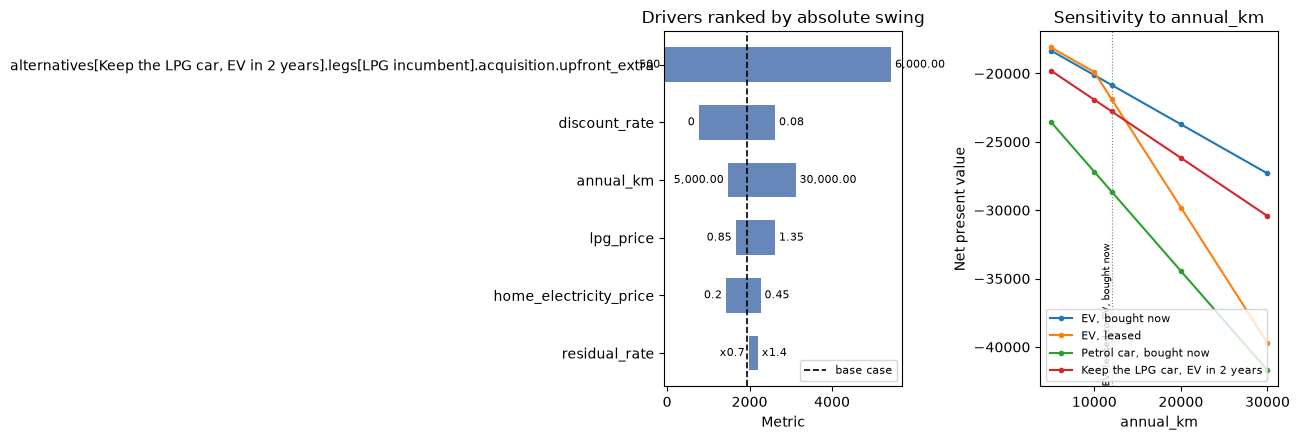

In [17]:
import matplotlib.pyplot as plt

from carbitrage.reporting.viz import one_way_plot, tornado_plot

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4.5))
tornado_plot(drivers, ax=left)
one_way_plot(grid, ax=right)
fig.tight_layout()

## 10. Uncertainty, done on the difference

`monte_carlo` returns the distribution of the **difference** between two
alternatives, not of each one separately, and the two energy prices are
correlated. Both choices matter: options that share an energy price move
together, so the spread of each alternative alone says nothing about how often
one of them wins.

In [18]:
simulation = result.monte_carlo(
    {
        "lpg_price": Triangular(0.80, 0.99, 1.40),
        "home_electricity_price": Triangular(0.22, 0.30, 0.45),
    },
    between=(A1, A4),
    correlation=[[1.0, 0.6], [0.6, 1.0]],
    n=1_000,
    seed=20260821,
)
print(simulation.describe())

EV, bought now beats Keep the LPG car, EV in 2 years in 100.0% of 1,000 trials.  Median advantage 1,983, 5th to 95th percentile 1,684 to 2,340.


## 11. Scenarios: expected value *and* regret

Scenarios overlay named bundles of overrides. Both decision rules are reported,
because when probabilities are soft they can disagree — and that disagreement is
the finding, not something to average away.

In [19]:
from carbitrage import Scenario, ScenarioSet

overlays = ScenarioSet(
    [
        Scenario("fuel collapse", {"lpg_price": 0.65, "petrol_price": 1.40}, probability=0.15),
        Scenario("subsidy expires by 2028", {DEFERRED_SUBSIDY: 0}, probability=0.30),
        Scenario("the old car dies early", {REPAIR: 6_000.0}, probability=0.25),
    ]
)
analysis = overlays.run(result.case)
md(analysis.to_markdown())
print("robust across scenarios:", analysis.is_robust())

| Alternative | base case | fuel collapse | subsidy expires by 2028 | the old car dies early | Expected | Max regret |
|---|---:|---:|---:|---:|---:|---:|
| EV, bought now | -20,844 | -20,844 | -20,844 | -20,844 | -20,844 | 0 |
| EV, leased | -21,880 | -21,880 | -21,880 | -21,880 | -21,880 | 1,036 |
| Petrol car, bought now | -28,638 | -25,733 | -28,638 | -28,638 | -28,202 | 7,794 |
| Keep the LPG car, EV in 2 years | -22,774 | -22,004 | -26,508 | -26,274 | -24,654 | 5,664 |

| Scenario | Winner |
|---|---|
| base case | EV, bought now |
| fuel collapse | EV, bought now |
| subsidy expires by 2028 | EV, bought now |
| the old car dies early | EV, bought now |

Highest expected value: **EV, bought now**.
Lowest worst-case regret: **EV, bought now** (0).
The same alternative wins in every scenario, so the choice is robust.

robust across scenarios: True


## 12. How long to keep it

The classical replacement question, answered by minimising equivalent annual cost
over candidate holding periods. The U-shaped curve only appears when running
costs actually grow with age — with flat costs the annuity falls monotonically
and the "optimum" is just the longest candidate, which says something about the
inputs rather than about replacement policy.

In [20]:
ages = optimal_replacement_age(
    buy_ev,
    timeline=timeline,
    candidates=[3, 4, 5, 6, 8, 10, 12],
    usage=usage,
    household=household,
)
for age, _pv, eac in ages.as_rows():
    print(f"{age:>4.0f} years   EAC {eac:>9,.0f}")
print(f"cheapest at {ages.best_age:g} years")

   3 years   EAC     4,369
   4 years   EAC     4,331
   5 years   EAC     4,237
   6 years   EAC     4,125
   8 years   EAC     3,898
  10 years   EAC     3,694
  12 years   EAC     3,521
cheapest at 12 years


## Before you trust any of it

Every number above rests on one assumption doing a great deal of work: that all
four alternatives deliver **the same service over the same horizon**. Range,
charging time and comfort are not monetised — and where a difference cannot be
defended in euros it does not appear here. If one option is materially more car
than another, the comparison is not merely incomplete but **invalid**, and no
amount of care downstream repairs it.

The genuinely uncertain input is the residual value curve. Note also that a
depreciation rate read off used-car prices is a *nominal* rate of decline; on a
real basis, restate it as `1 - (1 - nominal) / (1 + inflation)`.

To hand the result to someone who does not run notebooks:

```python
from carbitrage.reporting import write_excel
write_excel(result, "comparison.xlsx", baseline=A4, scenarios=analysis)
```